# Preprocessing et entraînement (Deep Learning - Fine-tuning GPT2)
*(Génération de **descriptions d'exercices sportifs**)*

**Datasets Kaggle (utilisés pour l'entraînement)** :  
- [Gym Exercise Dataset – Kaggle](https://www.kaggle.com/datasets/niharika41298/gym-exercise-data?resource=download)
- [Gym Exercises Dataset – Kaggle](https://www.kaggle.com/datasets/rishitmurarka/gym-exercises-dataset/data)

**Datasets Kaggle (utilisés pour la validation)** :  
- [Best 50 Exercise for your body – Kaggle](https://www.kaggle.com/datasets/prajwaldongre/best-50-exercise-for-your-body)

## Imports

In [90]:
# Bibliothèques principales
import warnings
import platform
from pathlib import Path
from datetime import datetime
import random
import math
import json
import re
import sys

# Imports Python / data science classiques
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from itables import show

# PyTorch & HuggingFace (version Transformers pour la distillation GPT-2)
import torch
from torch.utils.data import Dataset, TensorDataset, DataLoader, random_split
from torch.optim import AdamW
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
from transformers import pipeline, set_seed, get_scheduler
from tqdm.auto import tqdm

## Configuration

### Configuration GPU / CPU

In [91]:
warnings.filterwarnings("ignore")

# Infos système
print("TrAIn.me [Execution Generator] — Environnement Windows (PyTorch / Transformers)\n")
print(f"Système      : {platform.system()} {platform.release()}")
print(f"Architecture : {platform.machine()}")

# GPU / CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nGPU détecté : {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("\nAucun GPU CUDA détecté — utilisation du CPU (plus lent)")

TrAIn.me [Execution Generator] — Environnement Windows (PyTorch / Transformers)

Système      : Windows 10
Architecture : AMD64

Aucun GPU CUDA détecté — utilisation du CPU (plus lent)


### Configuration graphiques

In [92]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

root = Path.cwd()
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("Ajouté au PYTHONPATH :", themes_root)
print("Contenu de", themes_root, ":", [x.name for x in (themes_root).iterdir()])

# Thème personnalisé du projet (uniquement pour les notebooks)
from themes.theme_train_me import set_trainme_theme

# Appliquer le thème graphique TrAIn.me
set_trainme_theme()

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Le notebook s’exécute depuis son répertoire → on peut repartir du cwd
current_dir = Path.cwd()
project_root = current_dir.parents[3]  # remonte jusqu’à "train.me"

# Thème TrAIn.me (Seaborn/Matplotlib)=
palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
palette_trainme

Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['dataset_fusion', 'eda', 'model_training', 'preprocessing', 'themes', '__init__.py', '__pycache__']


['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Header expérimental

In [ ]:
# Seeds pour la reproductibilité
SEED_GLOBAL = 42
random.seed(SEED_GLOBAL)
np.random.seed(SEED_GLOBAL)
torch.manual_seed(SEED_GLOBAL)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_GLOBAL)

OUTPUT_MODEL_NAME = "transformer_execution_generator_v7"

# CHECKPOINT = "distilgpt2"
# CHECKPOINT = "gpt2"   # Teacher = GPT-2 Base (~124M)
# CHECKPOINT = "gpt2-medium"   # Teacher = GPT-2 Medium (345M)
CHECKPOINT = "gpt2-large"   # À garder pour plus tard --> machine plus musclée ou du cloud.
# CHECKPOINT = "microsoft/DialoGPT-medium"
# CHECKPOINT = "microsoft/DialoGPT-large"

# Longueur des séquences
MAX_LENGTH = 256
# Batch & split
BATCH_SIZE = 8
# Nombre d'époques d'entraînement
EPOCHS = 12
LR = 2e-5

### Affichage des versions d'imports

In [94]:
print("\nVersions utilisées :")
print(f"  - torch        : {torch.__version__}")
print(f"  - transformers : {transformers.__version__}")
# print("  - datasets     : installé (HuggingFace Datasets)")
print("\nEnvironnement configuré — prêt pour le fine-tuning GPT-2 spécialisée TrAIn.me [Execution Generator] !")


Versions utilisées :
  - torch        : 2.9.1+cpu
  - transformers : 4.57.3

Environnement configuré — prêt pour le fine-tuning GPT-2 spécialisée TrAIn.me [Execution Generator] !


## Téléchargement KaggleHub

In [95]:
def load_first_csv_from_kagglehub(dataset_name: str) -> pd.DataFrame:
    """
    Télécharge un dataset via kagglehub et charge automatiquement
    le premier CSV trouvé dans le dossier.
    """
    path = Path(kagglehub.dataset_download(dataset_name))
    csv_files = list(path.rglob("*.csv"))
    
    if not csv_files:
        raise FileNotFoundError(f"Aucun CSV trouvé dans {path}")
    
    print(f"Dataset '{dataset_name}' chargé depuis : {path}")
    print(f"--> CSV utilisé : {csv_files[0].name}")
    
    return pd.read_csv(csv_files[0]), csv_files[0]

# Téléchargement des trois datasets Kaggle
df_gym_exercise_data, file_gym_exercise_data = load_first_csv_from_kagglehub("niharika41298/gym-exercise-data")
df_gym_exercises_dataset, file_gym_exercises_dataset = load_first_csv_from_kagglehub("rishitmurarka/gym-exercises-dataset")
df_best_50_exercise_for_your_body, file_best_50_exercise_for_your_body = load_first_csv_from_kagglehub("prajwaldongre/best-50-exercise-for-your-body")

print("Gym Exercise Dataset:", df_gym_exercise_data.shape)
print("Gym Exercises Dataset:", df_gym_exercises_dataset.shape)
print("Best 50 Exercise for your body:", df_best_50_exercise_for_your_body.shape)

show(df_gym_exercise_data.head(3))
show(df_gym_exercises_dataset.head(3))
show(df_best_50_exercise_for_your_body.head(3))

Dataset 'niharika41298/gym-exercise-data' chargé depuis : C:\Users\fback\.cache\kagglehub\datasets\niharika41298\gym-exercise-data\versions\1
--> CSV utilisé : megaGymDataset.csv
Dataset 'rishitmurarka/gym-exercises-dataset' chargé depuis : C:\Users\fback\.cache\kagglehub\datasets\rishitmurarka\gym-exercises-dataset\versions\1
--> CSV utilisé : gym_exercise_dataset.csv
Dataset 'prajwaldongre/best-50-exercise-for-your-body' chargé depuis : C:\Users\fback\.cache\kagglehub\datasets\prajwaldongre\best-50-exercise-for-your-body\versions\1
--> CSV utilisé : Top 50 Excerice for your body.csv
Gym Exercise Dataset: (2918, 9)
Gym Exercises Dataset: (617, 17)
Best 50 Exercise for your body: (50, 8)


Loading ITables v2.5.2 from the internet... (need help?)


Loading ITables v2.5.2 from the internet... (need help?)


Loading ITables v2.5.2 from the internet... (need help?)


## Affichage des informations des datasets

In [96]:
# Forme des données et en-têtes de colonnes
print("Gym Exercise Dataset:\n")
df_gym_exercise_data.info()
print("-------------------------\n")

print("Gym Exercises Dataset:\n")
df_gym_exercises_dataset.info()
print("-------------------------\n")

print("Best 50 Exercise for your body:\n")
df_best_50_exercise_for_your_body.info()
print("-------------------------\n")

Gym Exercise Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2918 non-null   int64  
 1   Title       2918 non-null   object 
 2   Desc        1368 non-null   object 
 3   Type        2918 non-null   object 
 4   BodyPart    2918 non-null   object 
 5   Equipment   2886 non-null   object 
 6   Level       2918 non-null   object 
 7   Rating      1031 non-null   float64
 8   RatingDesc  862 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 205.3+ KB
-------------------------

Gym Exercises Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Exercise Name               617 non-null    object 
 1   Equipment               

## Harmonisation des colonnes

Schéma commun entre les 3 datasets

In [97]:
CANONICAL_COLS = [
    "exercise_name", # Nom de l'exercice
    "execution",# Description / Execution
    "target_muscles", # BodyPart / Target_Muscles / Target muscle Group
    "equipment", # Equipment / Equipment needed
    "difficulty", # Level / Difficulty level
    "source_dataset", # d'où vient la ligne
]

## Preprocessing

### Gym Exercise Dataset (niharika41298)

Définition des colonnes input / output :
- Title → exercise_name
- Desc → execution
- BodyPart → target_muscle
- Equipment → equipment
- Level → difficulty

In [98]:
df_gym_exercise_data = pd.DataFrame({
    "exercise_name":  df_gym_exercise_data["Title"],
    "execution":      df_gym_exercise_data["Desc"],
    "target_muscle": df_gym_exercise_data["BodyPart"],
    "equipment":      df_gym_exercise_data["Equipment"],
    "difficulty":     df_gym_exercise_data["Level"],
})
df_gym_exercise_data["source_dataset"] = "gym_exercise_data_niharika41298"
show(df_gym_exercise_data.head(10))

Loading ITables v2.5.2 from the internet... (need help?)


#### Audit qualité

In [99]:
# Audit qualité
missing_pct = df_gym_exercise_data.isna().mean().sort_values(ascending=False) * 100
dup_count = df_gym_exercise_data.duplicated().sum()

summary_types = pd.DataFrame({
    "dtype": df_gym_exercise_data.dtypes.astype(str),
    "n_unique": df_gym_exercise_data.nunique(),
    "missing_%": df_gym_exercise_data.isna().mean() * 100
}).sort_values("missing_%", ascending=False)

print(f"Doublons détectés (avant): {dup_count}")
display(missing_pct.to_frame("missing_%").head(20))
display(summary_types.head(20))

Doublons détectés (avant): 9


,missing_%
execution,53.118574
equipment,1.096642
exercise_name,0.000000
target_muscle,0.000000
difficulty,0.000000
source_dataset,0.000000


,dtype,n_unique,missing_%
execution,object,1050,53.118574
equipment,object,12,1.096642
exercise_name,object,2909,0.000000
target_muscle,object,17,0.000000
difficulty,object,3,0.000000
source_dataset,object,1,0.000000


#### Doublons & incohérences

In [100]:
# Doublons
rows_before = df_gym_exercise_data.shape[0]
dup_total = df_gym_exercise_data.duplicated().sum()
df_gym_exercise_data = df_gym_exercise_data.drop_duplicates().reset_index(drop=True)
rows_after = df_gym_exercise_data.shape[0]

clean_report = pd.DataFrame({
    "rows_before":[rows_before],
    "rows_after":[rows_after],
    "duplicates_removed":[dup_total],
    "cols":[df_gym_exercise_data.shape[1]]
})
show(clean_report)

Loading ITables v2.5.2 from the internet... (need help?)


#### Suppression des lignes sans "execution"

In [101]:
rows_before = df_gym_exercise_data.shape[0]

df_gym_exercise_data = df_gym_exercise_data[
    df_gym_exercise_data["execution"].notna() & # enlève NaN
    (df_gym_exercise_data["execution"].astype(str).str.strip() != "") # enlève vides
].reset_index(drop=True)

rows_after = df_gym_exercise_data.shape[0]

print(f"Lignes avant  : {rows_before}")
print(f"Lignes après  : {rows_after}")
print(f"Supprimées    : {rows_before - rows_after}")

Lignes avant  : 2909
Lignes après  : 1359
Supprimées    : 1550

Lignes après  : 1359
Supprimées    : 1550


In [102]:
show(df_gym_exercise_data.head(10))

Loading ITables v2.5.2 from the internet... (need help?)


### Gym Exercises Dataset (rishitmurarka)

Définition des colonnes input / output :
- Exercise Name → exercise_name
- Execution → execution
- Target_Muscles → target_muscles
- Equipement → equipment
- Difficulty (1-5) → difficulty

In [103]:
df_gym_exercises_dataset = pd.DataFrame({
    "exercise_name":  df_gym_exercises_dataset["Exercise Name"],
    "execution":      df_gym_exercises_dataset["Execution"],
    "target_muscle": df_gym_exercises_dataset["Target_Muscles"],
    "equipment":      df_gym_exercises_dataset["Equipment"],
    "difficulty":     df_gym_exercises_dataset["Difficulty (1-5)"],
})
df_gym_exercises_dataset["source_dataset"] = "gym_exercises_data_rishitmurarka"
show(df_gym_exercises_dataset.head(10))

Loading ITables v2.5.2 from the internet... (need help?)


#### Audit qualité

In [104]:
# Audit qualité
missing_pct = df_gym_exercises_dataset.isna().mean().sort_values(ascending=False) * 100
dup_count = df_gym_exercises_dataset.duplicated().sum()

summary_types = pd.DataFrame({
    "dtype": df_gym_exercises_dataset.dtypes.astype(str),
    "n_unique": df_gym_exercises_dataset.nunique(),
    "missing_%": df_gym_exercises_dataset.isna().mean() * 100
}).sort_values("missing_%", ascending=False)

print(f"Doublons détectés (avant): {dup_count}")
show(missing_pct.to_frame("missing_%").head(20))
show(summary_types.head(20))

Doublons détectés (avant): 0


Loading ITables v2.5.2 from the internet... (need help?)


Loading ITables v2.5.2 from the internet... (need help?)


#### Doublons & incohérences

In [105]:
# Doublons
rows_before = df_gym_exercises_dataset.shape[0]
dup_total = df_gym_exercises_dataset.duplicated().sum()
df_gym_exercises_dataset = df_gym_exercises_dataset.drop_duplicates().reset_index(drop=True)
rows_after = df_gym_exercises_dataset.shape[0]

clean_report = pd.DataFrame({
    "rows_before":[rows_before],
    "rows_after":[rows_after],
    "duplicates_removed":[dup_total],
    "cols":[df_gym_exercises_dataset.shape[1]]
})
show(clean_report)

Loading ITables v2.5.2 from the internet... (need help?)


#### Suppression des lignes sans "execution"

In [106]:
rows_before = df_gym_exercises_dataset.shape[0]

df_gym_exercises_dataset = df_gym_exercises_dataset[
    df_gym_exercises_dataset["execution"].notna() & # enlève NaN
    (df_gym_exercises_dataset["execution"].astype(str).str.strip() != "") # enlève vides
].reset_index(drop=True)

rows_after = df_gym_exercises_dataset.shape[0]

print(f"Lignes avant  : {rows_before}")
print(f"Lignes après  : {rows_after}")
print(f"Supprimées    : {rows_before - rows_after}")

Lignes avant  : 617
Lignes après  : 617
Supprimées    : 0


#### Nettoyage colonne "target_muscles"

In [107]:
show(df_gym_exercises_dataset["target_muscle"].head(2))
df_gym_exercises_dataset["target_muscle"] = (
    df_gym_exercises_dataset["target_muscle"]
        .astype(str)
        .str.strip()
        .str.rstrip(",")          
        .str.strip()
)
show(df_gym_exercises_dataset["target_muscle"].head(10))

Loading ITables v2.5.2 from the internet... (need help?)


Loading ITables v2.5.2 from the internet... (need help?)


#### Harmonisation colonne "difficulty"
Règle pour les notes 1–5 :
- 1–2 → "Beginner"
- 3 → "Intermediate"
- 4–5 → "Expert"

In [108]:
# Harmonisation de la difficulté dans df_gym_exercises_dataset
# (colonne numérique 1–5 → "Beginner" / "Intermediate" / "Expert")
def map_numeric_difficulty(val):
    if pd.isna(val):
        return None
    
    # Gestion des formats type "1\n2\n3" ou "1, 2, 3"
    text = str(val).replace("\n", ",")
    parts = [p.strip() for p in text.split(",") if p.strip()]
    
    scores = []
    for p in parts:
        try:
            scores.append(int(float(p)))
        except ValueError:
            continue
    
    if not scores:
        return None
    
    score = max(scores)  # on garde le niveau le plus élevé

    if score <= 2:
        return "Beginner"
    elif score == 3:
        return "Intermediate"
    else:  # 4 ou 5
        return "Expert"

df_gym_exercises_dataset["difficulty"] = df_gym_exercises_dataset["difficulty"].apply(map_numeric_difficulty)

# Petit check
print(df_gym_exercises_dataset["difficulty"].value_counts(dropna=False))

difficulty
Intermediate    254
Beginner        250
Expert          113
Name: count, dtype: int64


In [109]:
show(df_gym_exercises_dataset.head(10))

Loading ITables v2.5.2 from the internet... (need help?)


### Best 50 Exercise for your body (prajwaldongre)

Ce dataset ne contient pas de colonne descriptive, on pourra s'en servir pour le remplir automatiquement lors de la validation du modèle.

Définition des colonnes input / output :
- Name of Exercise → exercise_name
- Description → execution
- BodyPart → target_muscles
- Equipment → equipment
- Level → difficulty

Dans ce dataset, Equipment Needed = "None" signifie que l’exercice peut être réalisé sans aucun équipement.
Donc ce sont des bodyweight exercises, c’est-à-dire des exercices au poids du corps :
- Push-ups → bodyweight
- Squats (sans précision) → bodyweight
- Lunges → bodyweight
- Burpees → bodyweight
- Mountain climbers → bodyweight
- Jumping jacks → bodyweight
- Bicycle crunches → bodyweight

In [110]:
df_best_50_exercise_for_your_body = pd.DataFrame({
    "exercise_name":  df_best_50_exercise_for_your_body["Name of Exercise"],
    # pas de description dans ce dataset
    "execution":      pd.NA,
    "target_muscle": df_best_50_exercise_for_your_body["Target Muscle Group"],
    # harmonisation de l'équipement : None -> Bodyweight
    "equipment":      df_best_50_exercise_for_your_body["Equipment Needed"]
                           .replace({"None": "Bodyweight"})
                           .fillna("Bodyweight"),
    "difficulty":     df_best_50_exercise_for_your_body["Difficulty Level"],
})

df_best_50_exercise_for_your_body["source_dataset"] = "best_50_exercises_prajwaldongre"

show(df_best_50_exercise_for_your_body.head(10))

Loading ITables v2.5.2 from the internet... (need help?)


#### Audit qualité

In [111]:
# Audit qualité
missing_pct = df_best_50_exercise_for_your_body.isna().mean().sort_values(ascending=False) * 100
dup_count = df_best_50_exercise_for_your_body.duplicated().sum()

summary_types = pd.DataFrame({
    "dtype": df_best_50_exercise_for_your_body.dtypes.astype(str),
    "n_unique": df_best_50_exercise_for_your_body.nunique(),
    "missing_%": df_best_50_exercise_for_your_body.isna().mean() * 100
}).sort_values("missing_%", ascending=False)

print(f"Doublons détectés (avant): {dup_count}")
show(missing_pct.to_frame("missing_%").head(20))
show(summary_types.head(20))

Doublons détectés (avant): 0


Loading ITables v2.5.2 from the internet... (need help?)


Loading ITables v2.5.2 from the internet... (need help?)


#### Doublons & incohérences

In [112]:
# Doublons
rows_before = df_best_50_exercise_for_your_body.shape[0]
dup_total = df_best_50_exercise_for_your_body.duplicated().sum()
df_best_50_exercise_for_your_body = df_best_50_exercise_for_your_body.drop_duplicates().reset_index(drop=True)
rows_after = df_best_50_exercise_for_your_body.shape[0]

clean_report = pd.DataFrame({
    "rows_before":[rows_before],
    "rows_after":[rows_after],
    "duplicates_removed":[dup_total],
    "cols":[df_best_50_exercise_for_your_body.shape[1]]
})
show(clean_report)

Loading ITables v2.5.2 from the internet... (need help?)


#### Exploser les lignes pour chaque muscle (colonne qui concatène plusieurs "target_muscle")

In [113]:
df_exploded = df_best_50_exercise_for_your_body.copy()

# Split sur la virgule --> liste de muscles
df_exploded["target_muscle"] = (
    df_exploded["target_muscle"]
        .astype(str)
        .str.split(",")
)

# Explode : une ligne par muscle
df_exploded = df_exploded.explode("target_muscle").reset_index(drop=True)

# Nettoyage des espaces / valeurs vides
df_exploded["target_muscle"] = (
    df_exploded["target_muscle"]
        .astype(str)
        .str.strip()
)
df_exploded = df_exploded[df_exploded["target_muscle"] != ""].reset_index(drop=True)

# Renommer l'exercice en ajoutant le muscle entre parenthèses
df_exploded["exercise_name"] = (
    df_exploded["exercise_name"].astype(str).str.strip()
    + " (" + df_exploded["target_muscle"] + ")"
)

# Petit contrôle
show(df_exploded.head(10))
print("Shape avant :", df_best_50_exercise_for_your_body.shape)
print("Shape après :", df_exploded.shape)

df_best_50_exercise_for_your_body = df_exploded

Loading ITables v2.5.2 from the internet... (need help?)


Shape avant : (50, 6)
Shape après : (106, 6)


In [114]:
show(df_best_50_exercise_for_your_body.head(10))

Loading ITables v2.5.2 from the internet... (need help?)


## Fusion (df_gym_exercise_data et df_gym_exercises_dataset) + nettoyage

La fusion se fait sur "Gym Exercise Dataset (niharika41298)" et "Best 50 Exercise for your body (prajwaldongre)" avec des valeurs dans la colonne "execution" --> c'est notre base d'entraînement.

On laisse "Best 50 Exercise for your body (prajwaldongre)" de côté pour les tests finaux.

In [115]:
df_execution_generator = pd.concat([df_gym_exercise_data, df_gym_exercises_dataset], ignore_index=True)

# trim espaces, mettre en lower pour certains champs
for col in ["exercise_name", "target_muscle", "equipment", "difficulty"]:
    df_execution_generator[col] = (
        df_execution_generator[col]
        .astype("string")
        .str.strip()
    )

# Optionnel : supprimer les doublons sur nom + muscles
df_all_unique = df_execution_generator.drop_duplicates(
    subset=["exercise_name", "target_muscle", "equipment"],
    keep="first"
).reset_index(drop=True)

print("Shape fusion brute :", df_execution_generator.shape)
print("Shape après dédoublonnage :", df_all_unique.shape)

df_execution_generator = df_all_unique
show(df_execution_generator.head(20))

Shape fusion brute : (1976, 6)
Shape après dédoublonnage : (1976, 6)


Loading ITables v2.5.2 from the internet... (need help?)


### Cohérence "Bodyweight" / "Body Only" / "Body Weight"

In [116]:
subset_body_only = df_execution_generator[df_execution_generator["equipment"] == "Body Only"]

print("Nombre d'exercices Body Only :", subset_body_only.shape[0])
show(subset_body_only.head(20))

Nombre d'exercices Body Only : 404


Loading ITables v2.5.2 from the internet... (need help?)


In [117]:
subset_body_only = df_execution_generator[df_execution_generator["equipment"] == "Body Weight"]

print("Nombre d'exercices Body Weight :", subset_body_only.shape[0])
show(subset_body_only.head(20))

Nombre d'exercices Body Weight : 76


Loading ITables v2.5.2 from the internet... (need help?)


In [118]:
df_execution_generator["equipment"] = (
    df_execution_generator["equipment"]
        .astype(str).str.strip()
        .replace({
            "Body Only": "Bodyweight",
            "Body Weight": "Bodyweight",
            "Body-Weight": "Bodyweight",
            "None": "Bodyweight",
            "none": "Bodyweight",
            "body only": "Bodyweight",
            "body weight": "Bodyweight",
            "Other": "Bodyweight",
            "<NA>": "Bodyweight",
        })
)

In [119]:
print(df_execution_generator["equipment"].value_counts())

equipment
Bodyweight                         590
Dumbbell                           305
Cable                              247
Barbell                            217
Machine                            121
Lever (selectorized)                80
Lever (plate loaded)                76
Kettlebells                         53
Bands                               47
Weighted                            34
Suspended                           31
Sled                                31
Exercise Ball                       28
Medicine Ball                       25
Smith                               21
E-Z Curl Bar                        14
Foam Roll                            8
Band-assisted                        7
Self-assisted                        6
Self-assisted​​​​​​​                 5
Lever (selectorized)​​​​​​​          4
Assisted                             4
Assisted (machine)                   3
Lever                                3
Assisted (partner)                   2
Suspension     

In [120]:
subset_body_only = df_execution_generator[df_execution_generator["equipment"] == "Bodyweight"]

print("Nombre d'exercices Body Only :", subset_body_only.shape[0])
show(subset_body_only.head(20))

Nombre d'exercices Body Only : 590


Loading ITables v2.5.2 from the internet... (need help?)


In [121]:
print(df_execution_generator["equipment"].value_counts())

equipment
Bodyweight                         590
Dumbbell                           305
Cable                              247
Barbell                            217
Machine                            121
Lever (selectorized)                80
Lever (plate loaded)                76
Kettlebells                         53
Bands                               47
Weighted                            34
Suspended                           31
Sled                                31
Exercise Ball                       28
Medicine Ball                       25
Smith                               21
E-Z Curl Bar                        14
Foam Roll                            8
Band-assisted                        7
Self-assisted                        6
Self-assisted​​​​​​​                 5
Lever (selectorized)​​​​​​​          4
Assisted                             4
Assisted (machine)                   3
Lever                                3
Assisted (partner)                   2
Suspension     

### Traitement sur Dataset fusionné

In [122]:
cols_to_drop = [
    "source_dataset"
]

# On supprime seulement celles qui existent (pour éviter les KeyError)
df_execution_generator = df_execution_generator.drop(columns=[c for c in cols_to_drop if c in df_execution_generator.columns], errors="ignore")

print(list(df_execution_generator.columns))

['exercise_name', 'execution', 'target_muscle', 'equipment', 'difficulty']


In [123]:
# Supprimer les lignes sans execution (déjà fait pour chaque dataset, c'est une sécurité)
df_execution_generator = df_execution_generator.dropna(subset=["execution"])
print("Entrées des données : ", df_execution_generator.shape[0])

Entrées des données :  1976


### Vérifications

In [124]:
df_execution_generator.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   exercise_name  1976 non-null   string
 1   execution      1976 non-null   object
 2   target_muscle  1976 non-null   string
 3   equipment      1976 non-null   object
 4   difficulty     1976 non-null   string
dtypes: object(2), string(3)
memory usage: 77.3+ KB


In [125]:
show(df_execution_generator.head())

Loading ITables v2.5.2 from the internet... (need help?)


### Suppression des descriptions contenant des balises HTML ou des URLs 

In [126]:
# On réindexe après nettoyage
df_execution_generator = df_execution_generator.reset_index(drop=True)

# On utilise ce motif simple pour détecter une balise HTML encodée
html_pattern = r"&lt;.*?>"

# On supprime toutes les lignes dont la colonne execution contient ce motif
df_execution_generator = df_execution_generator.drop(
    df_execution_generator[
        df_execution_generator["execution"].astype(str).str.contains(html_pattern, regex=True)
    ].index
)

print("Entrées restantes après suppression HTML/URLs :", df_execution_generator.shape[0])

Entrées restantes après suppression HTML/URLs : 1976


In [127]:
# Petit aperçu rapide des données après nettoyage
show(df_execution_generator.head())

Loading ITables v2.5.2 from the internet... (need help?)


### Trier le dataset selon la longueur du nom de l'exercice

In [128]:
# Ajouter une nouvelle colonne contenant la longueur du 'exercise_name'
df_execution_generator["exercise_name_length"] = df_execution_generator["exercise_name"].apply(len)

# Trier le DataFrame selon cette longueur (du plus court au plus long)
df_execution_generator = df_execution_generator.sort_values(by="exercise_name_length")

# Supprimer la colonne temporaire (elle ne sert plus)
df_execution_generator = df_execution_generator.drop(columns=["exercise_name_length"])

# Supprimer les exercices dont le nom est trop court
# (ex: "Squat" ou "Crunch" seuls peuvent être trop vagues pour guider un modèle génératif)
df_execution_generator = df_execution_generator[
    df_execution_generator["exercise_name"].apply(len) >= 15
]

# Afficher un aperçu des données triées / filtrées
show(df_execution_generator.head())

Loading ITables v2.5.2 from the internet... (need help?)


### Refactorisation des séquences de texte pour fine-tuning

In [129]:
df_execution_generator["concat_sequence"] = df_execution_generator.apply(
    lambda x: 
        f'The {x["exercise_name"].strip()} exercise for "{x["target_muscle"].strip()}" '
        f'with "{x["equipment"].strip()}" on "{x["difficulty"].strip()}" level: '
        f'{x["execution"].strip()}',
    axis=1
)

# Aperçu des premières lignes pour contrôle
show(df_execution_generator.head())

Loading ITables v2.5.2 from the internet... (need help?)


## Datavisualisation

### Calcul de la longueur des séquences dans la colonne "execution"

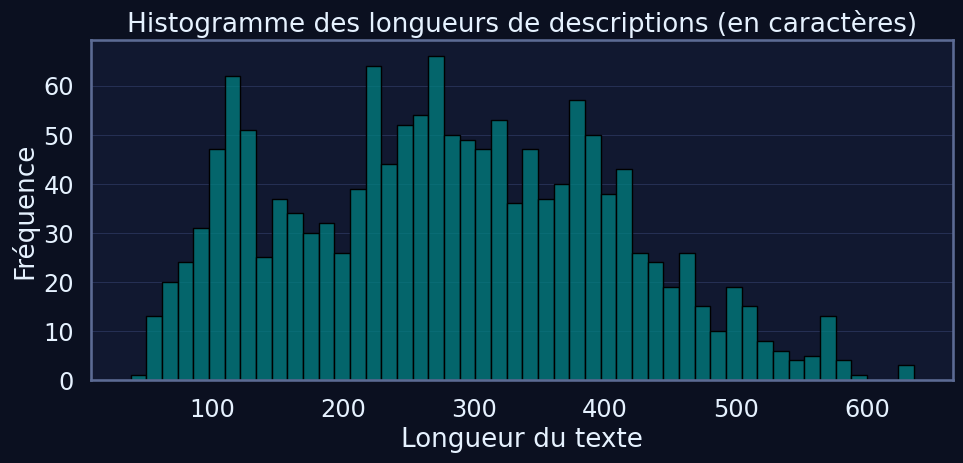

Loading ITables v2.5.2 from the internet... (need help?)


In [130]:
df_execution_generator['string_length'] = df_execution_generator['execution'].apply(len)

# Histogramme avec Seaborn
plt.figure(figsize=(10, 5))
sns.histplot(
    df_execution_generator['string_length'],
    bins=50, # valeur raisonnable pour lisibilité
    kde=False, # pas besoin de densité ici, mais tu peux l’activer
    color='teal',
    edgecolor='black'
)

plt.title('Histogramme des longueurs de descriptions (en caractères)')
plt.xlabel('Longueur du texte')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

# Affichage de contrôle
show(df_execution_generator.head())

### Calcul du nombre de mots dans chaque description 

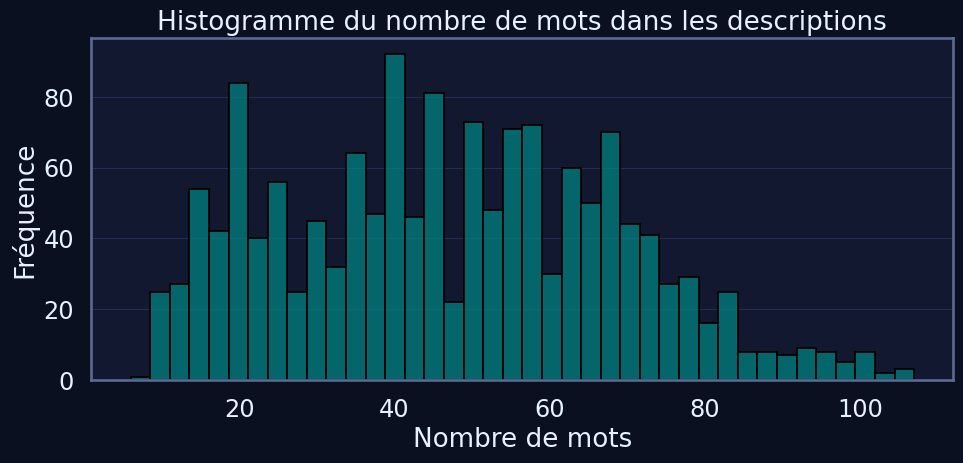

In [131]:
df_execution_generator["word_count"] = df_execution_generator["execution"].apply(
    lambda x: len(str(x).split())
)

# Histogramme
plt.figure(figsize=(10, 5))
sns.histplot(
    df_execution_generator["word_count"],
    bins=40, # valeur raisonnable pour lisibilité
    kde=False,
    color="teal",
    edgecolor="black"
)

plt.title("Histogramme du nombre de mots dans les descriptions")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

### Distribution par niveau de difficulté

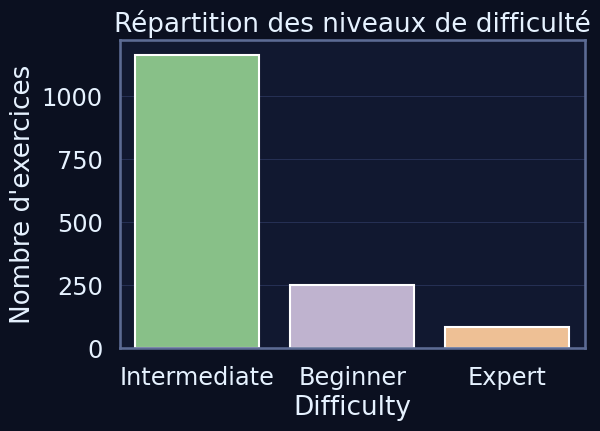

In [132]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_execution_generator, x="difficulty", palette="Accent")
plt.title("Répartition des niveaux de difficulté")
plt.xlabel("Difficulty")
plt.ylabel("Nombre d'exercices")
plt.show()

### Top 20 des muscles les plus fréquents

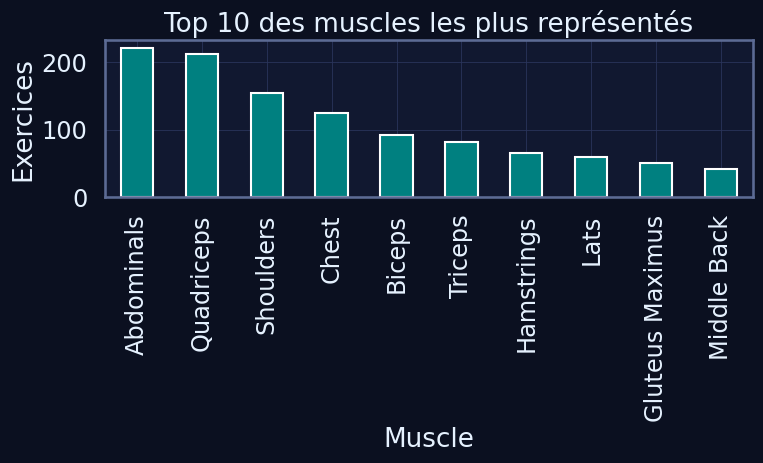

In [133]:
plt.figure(figsize=(8,5))
df_execution_generator["target_muscle"].value_counts().head(10).plot(kind="bar", color="teal")
plt.title("Top 10 des muscles les plus représentés")
plt.ylabel("Exercices")
plt.xlabel("Muscle")
plt.tight_layout()
plt.show()

### Longueur des descriptions par muscle

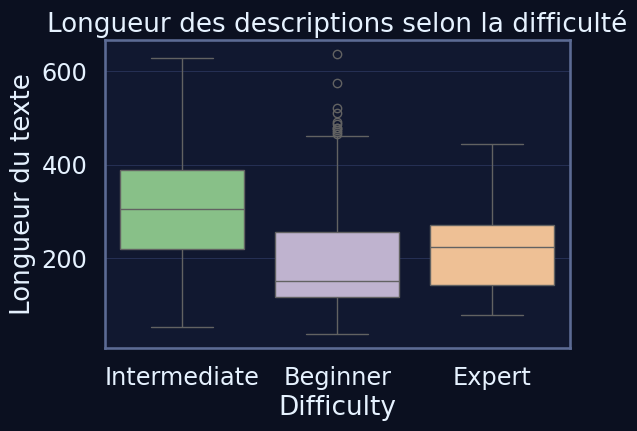

In [134]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_execution_generator,
    x="difficulty",
    y="string_length",
    palette="Accent"
)
plt.title("Longueur des descriptions selon la difficulté")
plt.xlabel("Difficulty")
plt.ylabel("Longueur du texte")
plt.show()

### Boxplot pour repérer les descriptions trop courte

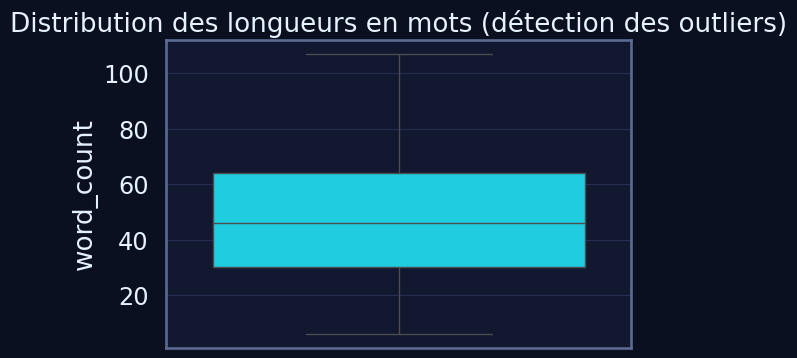

In [135]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_execution_generator["word_count"])
plt.title("Distribution des longueurs en mots (détection des outliers)")
plt.show()

## Entraînement du modèle

### Chargement du modèle Checkpoint

In [136]:
# Tokenizer avec padding à gauche
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT, padding_side="left")

# Certains GPT-2-like n'ont pas de pad_token --> on recycle eos_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Modèle PyTorch
model = AutoModelForCausalLM.from_pretrained(CHECKPOINT)
model = model.to(device)

### Vérification rapide du tokenizer et du modèle sur une phrase exemple

In [137]:
text = "This is a simple test sentence to validate the tokenizer and the model."

# Encodage du texte
encoded_input = tokenizer(
    text,
    return_tensors="pt",   # <-- sortie PyTorch
)

# Envoi optionnel sur le même device que le modèle
encoded_input = {k: v.to(device) for k, v in encoded_input.items()}

print("Tensors encodés :")
print(encoded_input)

# Passage dans le modèle (sans gradients)
with torch.no_grad():
    output = model(**encoded_input)   # <-- on transmet le dict tel quel

# Affichage de la forme des logits (batch, sequence_length, vocab_size)
print("\nShape des logits :", output.logits.shape)

Tensors encodés :
{'input_ids': tensor([[ 1212,   318,   257,  2829,  1332,  6827,   284, 26571,   262, 11241,
          7509,   290,   262,  2746,    13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

Shape des logits : torch.Size([1, 15, 50257])

Shape des logits : torch.Size([1, 15, 50257])


## Pipeline initiale

### Génération de texte avec le pipeline HuggingFace

In [138]:
# On utilise ici le tokenizer et le modèle déjà chargés précédemment dans le notebook.
generator = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    # device=0 => GPU si dispo, -1 => CPU
    device=0 if torch.cuda.is_available() else -1
)

# Rendre la génération déterministe
set_seed(42)

# On prend les lignes 3 à 6 (incluses), c’est-à-dire les index 3, 4, 5, 6
sample_prompts = df_execution_generator["concat_sequence"].iloc[3:7].tolist()

# Affichage des prompts sélectionnés
print("Prompts sélectionnés :")
for i, p in enumerate(sample_prompts, 1):
    print(f"\n--- PROMPT {i} ---\n{p}")

# Liste qui contiendra les textes générés
generated_outputs = []

# Génération pour chaque prompt
for prompt in sample_prompts:
    outputs = generator(
        prompt,
        # Nombre maximal de tokens générés après le prompt
        max_new_tokens=64,
        num_return_sequences=1,

        # Troncature explicite du prompt si celui-ci est trop long
        truncation=True,

        # Token de padding requis pour GPT-2
        pad_token_id=tokenizer.eos_token_id,
    )

    # Récupération du texte généré
    generated_outputs.append(outputs[0]["generated_text"])

# Affichage des résultats
print("\n RÉSULTATS DE GÉNÉRATION \n")
for i, text in enumerate(generated_outputs, 1):
    print(f"\n- OUTPUT {i}")
    print(text)

Device set to use cpu


Prompts sélectionnés :

--- PROMPT 1 ---
The Glute Ham Raise exercise for "Hamstrings" with "Machine" on "Intermediate" level: The glute ham raise is an exercise targeting the glutes and hamstrings on a GHD.

--- PROMPT 2 ---
The Decline Push-up exercise for "Pectoralis Major Clavicular" with "Bodyweight" on "Intermediate" level: Keeping body straight, lower upper body to floor by bending arms. To allow for full descent, pull head back slightly without arching back. Push body up until arms are extended. Repeat.

--- PROMPT 3 ---
The One Handed Hang exercise for "Lats" with "Bodyweight" on "Intermediate" level: The single-arm hang is a static exercise that involves hanging from a bar by one hand. It is an advanced hanging exercise that demands above-average shoulder stability and grip strength, and may not be appropriate for some people. However, if someone is strong and stable enough to perform it, the movement can help build those same qualities.

--- PROMPT 4 ---
The Warrior push-up 

In [140]:
# On prend les lignes 13 à 16 incluses (index 13 → 16)
sample_prompts = df_execution_generator["concat_sequence"].iloc[13:17].tolist()

print("Prompts sélectionnés :")
for i, p in enumerate(sample_prompts, 1):
    print(f"\nPROMPT {i}\n{p}")

# Génération pour chaque prompt
generated_outputs = []

for prompt in sample_prompts:
    outputs = generator(
        prompt,
        # Nombre maximal de tokens générés APRÈS le prompt
        max_new_tokens=64,
        num_return_sequences=1,

        # Troncature explicite si le prompt est trop long
        truncation=True,

        # Token de padding requis pour GPT-2
        pad_token_id=tokenizer.eos_token_id,
    )
    generated_outputs.append(outputs[0]["generated_text"])

# Affichage
print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(generated_outputs, 1):
    print(f"\n- OUTPUT {i}")
    print(text)

Prompts sélectionnés :

PROMPT 1
The Band Pull Apart exercise for "Shoulders" with "Bands" on "Intermediate" level: The band pull-apart is an exercise targeting the upper back muscles, including the trapezius, rear delts, and rhomboids. The band creates dynamic tension, allowing you to really focus on contracting these muscles, making it a great activation drill prior to upper-body lifting.

PROMPT 2
The Alligator Crawl exercise for "Abdominals" with "Bodyweight" on "Intermediate" level: The spider crawl is a bodyweight exercise that involves crawling on the floor with the knees outside of the elbows. It is different from a leopard crawl in that the hips are higher, and it's different from a bear crawl because the knees are wider. It can be done as a full-body warm-up, in short bursts for power or circuit training, or for longer durations as cardiovascular conditioning.

PROMPT 3
The Glute-Ham Raise exercise for "Hamstrings" with "Bodyweight" on "Expert" level: From upright position, l

## Preparation des données pour le fine-tuning

### Tokenisation du corpus complet

In [141]:
tokenized_data = tokenizer.batch_encode_plus(
    df_execution_generator["concat_sequence"].tolist(),
    return_tensors="pt", # <-- sortie au format PyTorch
    padding=True, # pad automatique pour uniformiser les batchs
    truncation=True, # coupe les séquences trop longues
    max_length=MAX_LENGTH, # longueur maximale autorisée
)

# Envoi des tenseurs sur le device (GPU si dispo, sinon CPU)
tokenized_data = {k: v.to(device) for k, v in tokenized_data.items()}

### Affichage des données tokenisées

In [142]:
print("Input IDs :")
print(tokenized_data["input_ids"])

print("\nAttention Mask :")
print(tokenized_data["attention_mask"])

Input IDs :
tensor([[50256, 50256, 50256,  ...,  1138,  1102,    13],
        [50256, 50256, 50256,  ...,  2618,  3047,    13],
        [50256, 50256, 50256,  ...,  1180, 18333,    13],
        ...,
        [50256, 50256, 50256,  ..., 10581,  1249,    13],
        [50256, 50256, 50256,  ...,    13, 30021,    13],
        [50256, 50256, 50256,  ...,  1180,  5642,    13]])

Attention Mask :
tensor([[0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1],
        ...,
        [0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1]])


### Inspection des types des objets manipulés

In [143]:
print("Type de tokenized_data :", type(tokenized_data)) # BatchEncoding / dict
print("Type de tokenized_data['input_ids'] :", type(tokenized_data["input_ids"])) # torch.Tensor

# Affichage du premier exemple tokenisé (une ligne du dataset)
print("\nPremier input_ids tokenisé :")
print(tokenized_data["input_ids"][:1])

# Clés disponibles dans la structure
print("\nClés présentes dans tokenized_data :", tokenized_data.keys())

Type de tokenized_data : <class 'dict'>
Type de tokenized_data['input_ids'] : <class 'torch.Tensor'>

Premier input_ids tokenisé :
tensor([[50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256,   464, 15903,   284,  2834,    12,   929,
          5517,   329,   366,    43,  1381,     1,   351,   366, 25842,  6551,
             1,   319,   366,  9492, 13857,     1,  1241,    25,   383,  4391,
           284,  2834,    12,   929,   318,   257,  1767,  6551,  5517,   326,
          6670,   262, 12749,   286,   262,   736,    11,   275, 41663,    11,
           290,    11,   284,   257, 14494,  4922,    11,  7405,    13,   632,
          9018, 14284,   510,   284,   257,  2834,    12,   929,  2318,  1022,
         20982,    13, 11014,   284,   257,  4574,    12,  8439,    11,   262,
          7405,  1037,  1176,   832,   262,   749,  2408,  6903,   286,   262,


## Dataset PyTorch

In [144]:
dataset = TensorDataset(
    tokenized_data["input_ids"],
    tokenized_data["attention_mask"],
    tokenized_data["input_ids"] # labels
)

# Création du DataLoader (batches de BATCH_SIZE)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE, # variable globale
    shuffle=True # important pour l'entraînement
)

print(f"Nombre total de batches : {len(dataloader)}")

Nombre total de batches : 188


### Construire un Dataset PyTorch

In [145]:
class CausalDataset(Dataset):
    def __init__(self, tokenized_data):
        self.input_ids = tokenized_data["input_ids"]
        self.attention_mask = tokenized_data["attention_mask"]

    def __len__(self):
        return self.input_ids.size(0)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.input_ids[idx],
        }

dataset = CausalDataset(tokenized_data)

### Construire un DataLoader PyTorch

In [146]:
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

### Vérification du batch

In [147]:
batch = next(iter(dataloader))
for k, v in batch.items():
    print(k, v.shape)

input_ids torch.Size([8, 172])
attention_mask torch.Size([8, 172])
labels torch.Size([8, 172])


### Examiner le premier batch

In [148]:
first_batch = next(iter(dataloader))

# Extraction via les clés du dictionnaire
input_ids = first_batch["input_ids"]
attention_mask = first_batch["attention_mask"]
labels = first_batch["labels"]

# On examine seulement le premier exemple
i = 0
print("Input IDs :", input_ids[i])
print("Texte décodé (input) :", tokenizer.decode(input_ids[i], skip_special_tokens=False))

print("\nAttention Mask :", attention_mask[i])

print("\nLabels IDs :", labels[i])
print("Texte décodé (labels) :", tokenizer.decode(labels[i], skip_special_tokens=False))

print("=" * 50)

Input IDs : tensor([50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256,   464, 14206,    12,  1455,
         9105,  1232, 29249,  5517,   329,   366, 21281, 37336,     1,   351,
          366, 37573,     1,   319,   366,  9492, 13857,     1,  1241,    25,
          383,  2060,    12,  1455,  9105,  1232, 29249,   318,   257,  2968,
         4572,    12,  3106,  5517,   329,   262,  7405,    11,  3573,   262,
         8891, 37336,    13,   632,   318,  2092,   284,   262, 21639,  1232,
        29249,    11,   475,   262,  1280, 10359,  9848,   287,   262,  9105,
         1232, 29249,   743, 19330,   517,  1278,  1133,   290, 31134, 14916,
           13,   632,   318,  3221,  6157,   329, 10768,   284,  1029, 20982,
           11,   884,   355,   807,    12,  1065, 20982,   583,   900,   393,
          517,    11,   355,   636,   286,   257,  1

## Train / Validation split

In [149]:
# Nombre total d'exemples dans le dataset
num_samples = len(dataset)
print(f"Nombre total d'exemples : {num_samples}")

# Nombre approximatif de batches
num_batches = math.ceil(num_samples / BATCH_SIZE)
print(f"{num_batches} batches de {BATCH_SIZE} exemples chacun.")

# Split 90% / 10%
train_size = int(0.9 * num_samples)
val_size = num_samples - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Taille du jeu d'entraînement : {train_size}")
print(f"Taille du jeu de validation : {val_size}")

# DataLoaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # important pour le training
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # on ne shuffle pas la validation
)

Nombre total d'exemples : 1497
188 batches de 8 exemples chacun.
Taille du jeu d'entraînement : 1347
Taille du jeu de validation : 150


## Configuration et compilation du modèle

### Optimiseur et scheduler

In [150]:
print(f"Nombre d'époques : {EPOCHS}")

# Nombre de batches par époque × nombre d'époques
num_update_steps_per_epoch = len(train_dataloader)
num_training_steps = num_update_steps_per_epoch * EPOCHS
print(f"Nombre total de training steps : {num_training_steps}")

# On utilise AdamW comme dans les entraînements GPT-2 officiels
optimizer = AdamW(model.parameters(), LR)

# Scheduler du taux d’apprentissage
# Scheduler linéaire = décroissance progressive du LR jusqu'à 0,
# équivalent à ton PolynomialDecay TensorFlow avec end_learning_rate = 0.
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0, # pas de warmup pour l’instant
    num_training_steps=num_training_steps,
)

print("Optimiseur et scheduler LR initialisés.")

Nombre d'époques : 12
Nombre total de training steps : 2028
Optimiseur et scheduler LR initialisés.


### Chargement de la configuration du modèle HuggingFace

In [151]:
config = AutoConfig.from_pretrained(CHECKPOINT)
print(config)

GPT2Config {
  "_num_labels": 1,
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "id2label": {
    "0": "LABEL_0"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0
  },
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 6,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.57.3",
  "use_cache": true,
  "vocab_size": 50257
}



### Récupération d’un batch d’entraînement et passage avant (forward pass)

In [152]:
batch = next(iter(train_dataloader))
batch = {k: v.to(device) for k, v in batch.items()}

outputs = model(**batch)

loss = outputs.loss
logits = outputs.logits

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


### Comptage des paramètres du modèle

In [153]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Nombre total de paramètres       : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")

Nombre total de paramètres       : 81,912,576
Nombre de paramètres entraînables : 81,912,576


## Entraînement du modèle

### Callback pour afficher le Learning Rate à chaque époque

In [154]:
class PrintLearningRate:
    def on_epoch_begin(self, epoch, optimizer):
        lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch + 1} — Learning Rate : {lr}")

### Callback d'affichage de l'évolution de la loss

In [155]:
class FineTuneVisualizer:
    """
    Visualisation dynamique du fine-tuning :
      - Courbe des losses train / val par époque
      - Barres avant / après pour l'amélioration globale
    """

    def __init__(self, total_epochs: int):
        self.total_epochs = total_epochs
        self.train_losses = []
        self.val_losses = []

    def update(self, epoch: int, train_loss: float, val_loss: float):
        # On stocke les nouvelles valeurs
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)

        # Rafraîchissement propre dans le notebook
        clear_output(wait=True)

        # Graphique
        plt.figure(figsize=(14, 5))

        # Courbe des pertes (train / val)
        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, "o-", label="Train Loss")
        plt.plot(self.val_losses, "o-", label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Progression du fine-tuning GPT (TrAIn.me Execution Generator)", fontsize=14)
        plt.grid(alpha=0.3)
        plt.legend()

        # Aperçu de l'amélioration globale
        plt.subplot(1, 2, 2)
        if len(self.train_losses) > 1:
            improvement = ((self.train_losses[0] - self.train_losses[-1]) /
                           self.train_losses[0]) * 100
            plt.bar(
                ["Initial", "Actuel"],
                [self.train_losses[0], self.train_losses[-1]],
                color=["lightcoral", "lightgreen"],
                edgecolor="black",
            )
            plt.title(f"Amélioration : {improvement:.1f}%", fontsize=14)
            plt.ylabel("Loss")
            plt.grid(alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

        # Log textuel
        print(f"Epoch {epoch + 1}/{self.total_epochs}")
        print(f"Train Loss : {train_loss:.4f} | Val Loss : {val_loss:.4f}")

### Boucle d'entraînement

In [ ]:
lr_callback = PrintLearningRate()
visualizer = FineTuneVisualizer(total_epochs=EPOCHS)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # LR callback
    lr_callback.on_epoch_begin(epoch, optimizer)

    # TRAIN LOOP
    model.train()
    running_train_loss = 0.0

    progress_bar = tqdm(train_dataloader, desc=f"Train epoch {epoch+1}", leave=False)

    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        running_train_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    avg_train_loss = running_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # VAL LOOP
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch in val_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)

    # Mise à jour du visualizer
    visualizer.update(epoch, avg_train_loss, avg_val_loss)

### Perplexité

In [ ]:
# On récupère la dernière validation loss enregistrée
final_val_loss = val_losses[-1]

# Calcul de la perplexité
perplexity = np.exp(final_val_loss)

print(f"Perplexité approx : {perplexity:.2f}")

## Tests de génération

### Reconstuction des prompts

In [ ]:
# Même logique de prompt pour le dataset de validation sans "execution"
df_best_50_exercise_for_your_body["prompts"] = df_best_50_exercise_for_your_body.apply(
    lambda x: 
        f'The {x["exercise_name"].strip()} exercise for '
        f'"{x["target_muscle"].strip()}" with '
        f'"{x["equipment"].strip()}" on '
        f'"{x["difficulty"].strip()}" level:',
    axis=1
)

# On prend les lignes 1 à 3 du dataset de validation final
sample_prompts = df_best_50_exercise_for_your_body["prompts"].iloc[1:4].tolist()
print(sample_prompts)

### Tokenisation d’une liste de prompts

In [ ]:
encodings = tokenizer(
    sample_prompts, # liste de phrases (lignes 20 à 23)
    return_tensors="pt", # sortie PyTorch
    padding=True, # pad à gauche (défini plus tôt)
    truncation=True # coupe si dépasse max_length défini pour le tokenizer
).to(device) # on place le tout sur CPU ou GPU selon config

### Fonction de suppression du prompt dans chaque génération

In [ ]:
def strip_prompt_from_generations(prompts, generated_outputs):
    """
    Supprime le prompt au début de chaque génération si le modèle l'a recopié.
    """
    
    cleaned = []
    
    for prompt, gen in zip(prompts, generated_outputs):
        gen_strip = gen.strip()
        
        if gen_strip.startswith(prompt):
            cleaned.append(gen_strip[len(prompt):].strip())
        else:
            cleaned.append(gen_strip)
    
    return cleaned

### Fonction pour tronquer le texte à la dernière phrase complète

In [ ]:
def trim_to_last_full_sentence(text: str) -> str:
    """
    Coupe le texte à la dernière phrase complète.
    On garde tout jusqu'au dernier '.', '!' ou '?'.
    Si aucun n'est trouvé, on renvoie le texte brut stripé.
    """
    text = text.strip()

    last_dot = text.rfind(".")
    last_excl = text.rfind("!")
    last_q = text.rfind("?")

    last_punct = max(last_dot, last_excl, last_q)

    if last_punct != -1:
        return text[: last_punct + 1].strip()
    return text

### Fonction pour limiter la longueur “perçue” par phrase

In [ ]:
def keep_first_n_sentences(text: str, n: int = 2) -> str:
    # Split grossier sur . ! ?
    sentences = re.split(r'([.!?])', text)
    chunks = []
    count = 0

    for i in range(0, len(sentences) - 1, 2):
        sentence = sentences[i].strip()
        punct = sentences[i + 1].strip()
        if sentence:
            chunks.append(sentence + punct)
            count += 1
        if count >= n:
            break

    return " ".join(chunks).strip() if chunks else text.strip()

### Fonction pour dédupliquer les muscles dans le texte

In [ ]:
def dedupe_muscle_list(text: str) -> str:
    """
    Détecte les listes du type 'glutes, hamstrings, and hamstrings'
    dans la phrase, les déduplique et les reformate proprement.
    """

    # Regex qui capture une liste séparée par virgules ou 'and'
    # Exemple capturé : "glutes, hamstrings, and hamstrings"
    pattern = r"([A-Za-z ]+(?:,\s*[A-Za-z ]+)*(?:\s+and\s+[A-Za-z ]+)?)"

    def process_match(match):
        segment = match.group(0)

        # Split sur virgules et 'and'
        parts = re.split(r",|\band\b", segment)
        parts = [p.strip() for p in parts if p.strip()]

        # Déduplique tout en gardant l’ordre
        seen = set()
        unique = []
        for p in parts:
            if p.lower() not in seen:
                seen.add(p.lower())
                unique.append(p)

        # Reconstruction naturelle
        if len(unique) == 1:
            return unique[0]

        if len(unique) == 2:
            return f"{unique[0]} and {unique[1]}"

        return ", ".join(unique[:-1]) + f", and {unique[-1]}"

    # Applique la fonction sur toutes les occurrences
    cleaned = re.sub(pattern, process_match, text)
    return cleaned

### Fonction de nettoyage “cosmétique”

In [ ]:
def clean_execution_text(text: str) -> str:
    if not isinstance(text, str):
        return text

    cleaned = text

    # Ajouter un espace après un point si collé à une majuscule
    cleaned = re.sub(r'(\.)([A-Z])', r'\1 \2', cleaned)

    # Ajouter un espace après "such as" si collé à un chiffre
    cleaned = re.sub(r"(such as)(\d)", r"\1 \2", cleaned)

    # Ajouter un espace avant "reps" si collé au chiffre
    cleaned = re.sub(r"(\d)(reps)", r"\1 reps", cleaned)

    # Normaliser les doubles espaces
    cleaned = re.sub(r"\s{2,}", " ", cleaned).strip()

    return cleaned

### Greedy Search
Greedy Search génère du texte en choisissant à chaque étape le token ayant la probabilité la plus élevée, ce qui rend la sortie déterministe mais parfois peu créative.

In [ ]:
# Génération de texte avec le modèle distillé
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    min_new_tokens=20, # forcé pour éviter les générations vides
    pad_token_id=tokenizer.eos_token_id,
)

# Décodage propre du batch --> conversion des tokens en texte lisible
generated_outputs = tokenizer.batch_decode(
    outputs,
    skip_special_tokens=True
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n- OUTPUT {i}")
    print("Prompt:", sample_prompts[i-1])
    print(text)


### Beam Search
Beam Search explore plusieurs suites de tokens en parallèle et ne conserve que les plus prometteuses, ce qui produit des textes plus cohérents et globablement meilleurs qu’un greedy pur.

In [ ]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH,# nombre maximum de tokens générés
    num_beams=5, # beam search pour améliorer la cohérence
    do_sample=True, # sampling activé pour ajouter de la diversité
    num_return_sequences=1, # une seule génération par prompt
    pad_token_id=tokenizer.eos_token_id,
    early_stopping=True, # arrêt si tous les beams atteignent EOS
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n- OUTPUT {i}")
    print("Prompt:", sample_prompts[i-1])
    print(text)

### n-gram Penalties
Les n-gram penalties empêchent le modèle de réutiliser plusieurs fois la même séquence de n tokens, réduisant ainsi les répétitions et rendant la génération plus fluide.

In [ ]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    num_beams=5, # beam search pour améliorer la cohérence
    do_sample=True, # sampling activé pour ajouter de la diversité
    num_return_sequences=1, # une seule génération par prompt
    pad_token_id=tokenizer.eos_token_id,
    early_stopping=True, # arrêt si tous les beams atteignent EOS
    no_repeat_ngram_size=2, # empêche les répétitions de 2-gram
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n- OUTPUT {i}")
    print("Prompt:", sample_prompts[i-1])
    print(text)

### Sampling
Sampling sélectionne chaque token aléatoirement selon la distribution de probabilités du modèle, ce qui produit des textes plus variés et créatifs qu'une stratégie déterministe.

In [ ]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    do_sample=True, # sampling activé pour ajouter de la diversité
    pad_token_id=tokenizer.eos_token_id,
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n- OUTPUT {i}")
    print("Prompt:", sample_prompts[i-1])
    print(text)

### Tweak the Temperature
Ajuster la temperature revient à rendre la distribution des probabilités plus plate (créatif) ou plus pointue (strict), influençant directement le niveau de diversité dans la génération.

In [ ]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    do_sample=True, # sampling activé pour ajouter de la diversité
    temperature=0.6, # modifie la "chaleur" de la distribution
    pad_token_id=tokenizer.eos_token_id,
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n- OUTPUT {i}")
    print("Prompt:", sample_prompts[i-1])
    print(text)

### Top-K Sampling
Top-K Sampling limite le choix du modèle aux K tokens les plus probables, équilibrant aléatoire et contrôle pour éviter des choix trop improbables.

In [ ]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    do_sample=True, # sampling activé pour ajouter de la diversité
    top_k=50, # top-K sampling (limite aux 50 tokens les plus probables)
    pad_token_id=tokenizer.eos_token_id,
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n- OUTPUT {i}")
    print("Prompt:", sample_prompts[i-1])
    print(text)

### Top-P (Nucleus) Sampling
Top-P (Nucleus) Sampling sélectionne les tokens au sein de la plus petite portion cumulative de probabilité P, garantissant diversité et cohérence en ne gardant que les choix réellement plausibles du modèle.

In [ ]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    do_sample=True, # sampling activé pour ajouter de la diversité
    top_p=0.92, # nucleus sampling (top-P)
    pad_token_id=tokenizer.eos_token_id,
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n- OUTPUT {i}")
    print("Prompt:", sample_prompts[i-1])
    print(text)

### Fine-tuning de génération gloable
Consiste à combiner plusieurs techniques de génération (greedy, sampling, top-k, top-p, pénalités, beam…) pour obtenir un comportement équilibré entre cohérence, contrôle et créativité.

In [ ]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    do_sample=True, # sampling activé pour ajouter de la diversité
    top_k=250, # top-K sampling large
    top_p=0.92, # nucleus sampling
    no_repeat_ngram_size=3, # évite les répétitions de 3-gram
    num_beams=5, # beam search pour améliorer la cohérence
    num_return_sequences=1, # une seule génération par prompt
    pad_token_id=tokenizer.eos_token_id,
    early_stopping=True, # arrêt anticipé si EOS atteint sur tous les beams
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n- OUTPUT {i}")
    print("Prompt:", sample_prompts[i-1])
    print(text)

### Phase 1 d'optimisations
(Voir notes à la fin du notebook pour plus de précisions)

In [ ]:
# Génération de texte avec réglages avancés
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    min_new_tokens=40, # longueur minimale pour éviter les textes trop courts
    do_sample=True, # sampling activé (obligatoire pour top-k / top-p)
    temperature=0.8, # légère "chauffe" pour plus de variété
    top_k=250, # top-K sampling large
    top_p=0.92, # nucleus sampling
    no_repeat_ngram_size=3, # évite les répétitions de 3-grams
    num_beams=5, # beam search pour améliorer la cohérence
    num_return_sequences=1, # une seule génération par prompt
    pad_token_id=tokenizer.eos_token_id,
    early_stopping=True, # arrêt anticipé si EOS atteint partout
)

# Décodage propre du batch → texte lisible
generated_outputs = tokenizer.batch_decode(
    outputs,
    skip_special_tokens=True,
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs,
)


# Coupe chaque génération à la dernière phrase complète
final_generations = [trim_to_last_full_sentence(txt) for txt in cleaned_generations]

# Affichage des générations
print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n- OUTPUT {i}")
    print("Prompt:", sample_prompts[i - 1])
    print(text)

### Phase 2 d'ptimisations
(Voir notes à la fin du notebook pour plus de précisions)

In [ ]:
# Génération
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    min_new_tokens=50, # longueur minimale pour éviter les textes trop courts
    do_sample=True, # sampling activé (obligatoire pour top-k / top-p)
    temperature=0.8, # légère "chauffe" pour plus de variété
    top_k=250, # top-K sampling large
    top_p=0.92, # nucleus sampling
    no_repeat_ngram_size=3, # évite les répétitions de 3-grams
    num_beams=5, # beam search pour améliorer la cohérence
    num_return_sequences=1, # une seule génération par prompt
    pad_token_id=tokenizer.eos_token_id,
    early_stopping=True, # arrêt anticipé si EOS atteint partout
)

generated_outputs = tokenizer.batch_decode(
    outputs,
    skip_special_tokens=True,
)

# On enlève le prompt au début de chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs,
)

# Post-traitement
trimmed  = [trim_to_last_full_sentence(txt) for txt in cleaned_generations]
limited  = [keep_first_n_sentences(t, n=2) for t in trimmed]
deduped  = [dedupe_muscle_list(t) for t in limited]
final    = [clean_execution_text(t) for t in deduped]

print("\nRÉSULTATS DE GÉNÉRATION\n")
for i, text in enumerate(final, 1):
    print(f"\n- OUTPUT {i}")
    print("Prompt:", sample_prompts[i - 1])
    print(text)

## Sauvegarde du modèle distillé (format HuggingFace)

In [ ]:
# Chemin du notebook courant
notebook_dir = Path().resolve()

# Racine du projet : notebooks/... --> remonter 3 niveaux
project_root = notebook_dir.parent.parent.parent

# Dossier final où stocker ton modèle distillé
save_dir = project_root / "models" / OUTPUT_MODEL_NAME
save_dir.mkdir(parents=True, exist_ok=True)

print(f"Sauvegarde du modèle dans : {save_dir}")

# Sauvegarde du modèle PyTorch HF
model.save_pretrained(save_dir)

# Sauvegarde du tokenizer associé
tokenizer.save_pretrained(save_dir)

# Vérification
print("\nContenu du dossier sauvegardé :")
for f in save_dir.iterdir():
    print("   -", f.name)

## Informations relatives au modèle (son nom et les métriques associées)

In [ ]:
print("\nEXECUTION GENERATOR — MODEL REPORT\n")

# Répertoire du modèle (même dossier que la sauvegarde)
model_dir = save_dir # défini lors de save_pretrained(...)
report_path = model_dir / "execution_generator_model_report.json"

# Récupération des métriques
final_train_loss = float(train_losses[-1]) if train_losses else None
final_val_loss   = float(val_losses[-1]) if val_losses else None
best_val_loss    = float(min(val_losses)) if val_losses else None

# On prend comme "best_loss" la meilleure val_loss si dispo, sinon la dernière train_loss
if best_val_loss is not None:
    best_loss = best_val_loss
else:
    best_loss = final_train_loss

# Taille du modèle
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
size_mb = total_params * 4 / (1024**2)   # float32 supposé

# Contexte d’évaluation
report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "task": "language_modeling",
    "target": "next_token_prediction (execution_generation)",
    "n_train_samples": int(len(train_dataset)) if "train_dataset" in globals() else None,
    "n_val_samples": int(len(val_dataset)) if "val_dataset" in globals() else None,
    "sequence_length": int(MAX_LENGTH),
    "device": str(device),

    "model": {
        "name": OUTPUT_MODEL_NAME,
        "type": "CausalLM_FineTuned",
        "class": model.__class__.__name__,
        "checkpoint_base": CHECKPOINT,
        "total_params": int(total_params),
        "trainable_params": int(trainable_params),
        "size_mb": round(size_mb, 2),
    },

    "training": {
        "epochs": int(EPOCHS),
        "learning_rate": float(LR),
        "batch_size": int(BATCH_SIZE),
        "seed_global": int(SEED_GLOBAL),
        "optimizer": "AdamW",
    },

    "metrics": {
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "best_val_loss": best_val_loss,
        "best_loss": best_loss,
    },
}

# Impression console
for section, value in report.items():
    if isinstance(value, dict):
        print(f"- {section}:")
        for k, v in value.items():
            print(f"    • {k}: {v}")
    else:
        print(f"- {section}: {value}")

# Enregistrement JSON
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"\nRapport JSON enregistré : {report_path}")

## Notes
Renseigner "target_muscles" et "equipment" en plus --> OK

Revoir la fusion des données pour améliorer la description --> OK

Eviter que les phrases de fin se coupent. --> OK

### **Optimisations 1**
- Activer no_repeat_ngram_size=3 ou 4 --> OK

        --> casse immédiatement les répétitions (“warm-up warm-up warm-up”).

- Utiliser top-p sampling + légère temperature --> OK

        --> variantes plus naturelles.

- Ajouter min_new_tokens=40 ou 50 --> OK

        --> descriptions plus complètes.

- Nettoyer ton corpus des répétitions internes

        --> éviter que le modèle n’apprenne des patterns cycliques.

- Continuer l’entraînement 1 à 3 epochs de plus --> OK

        --> stabilisation du style.

- Option : affiner l’entraînement sur un corpus encore plus propre

        --> moins bruité = meilleure cohérence.




### **Optimisations 2**

- Dédupliquer les muscles dans le texte --> OK

- Limiter la longueur “perçue” par phrase --> OK

- Changer de modèle à distiller "distillgpt2" > "gpt2" > "large"  --> OK

- Tester modèle Microsoftg  --> OK